# Linear Algebra: Mathematics and Computation
## Lecture 1 — A First Look: Something Strange Is Happening
**University of Austin · Spring 2026**

---

*You don't need to understand everything today. That's the point.*  
*Run the code, look at the pictures, notice what feels weird.*  
*By the last lecture, every surprise here will feel obvious.*

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Make plots look nice
plt.rcParams['figure.dpi'] = 120

---
## §1 — A Game That Started It All

In 1970, the mathematician John Conway invented a game played on an infinite grid of square cells.
Each cell is either **alive** or **dead**. Every tick, each cell looks at its eight neighbours
and decides whether to live or die:

- An **alive** cell survives if it has 2 or 3 alive neighbours; otherwise it dies.
- A **dead** cell is born if it has exactly 3 alive neighbours.

That's it. No physics, no equations, no randomness. Just a grid and a rule.

From this absurdly simple setup emerges something remarkable: the **glider** —
a five-cell pattern that moves diagonally, one step every four ticks, forever.

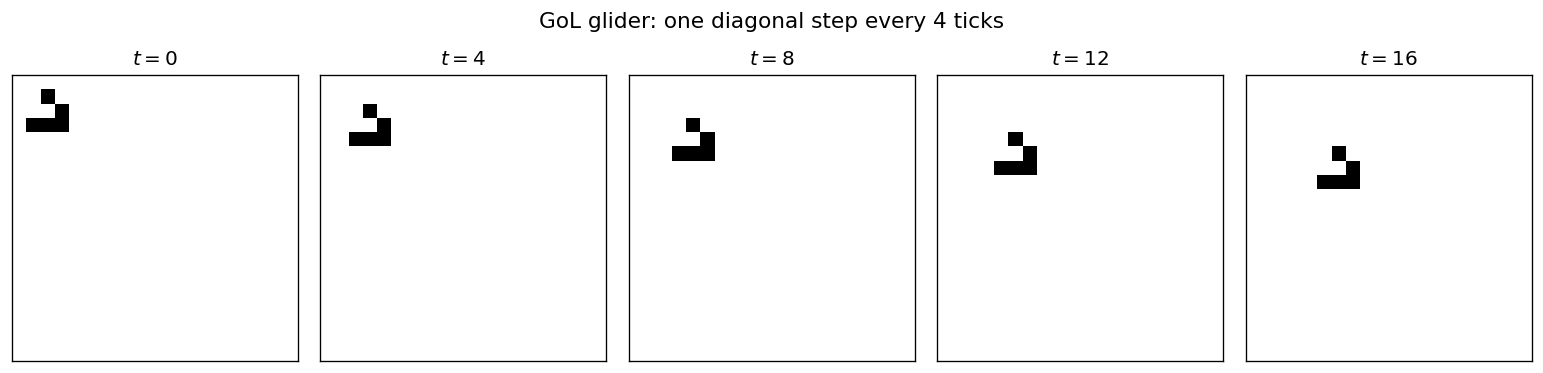

In [2]:
def gol_step(grid):
    """One tick of Conway's Game of Life on a toroidal (wrap-around) grid."""
    # Count alive neighbours for every cell at once
    nbrs = np.zeros_like(grid, dtype=int)
    for di in (-1, 0, 1):
        for dj in (-1, 0, 1):
            if di == 0 and dj == 0:
                continue
            nbrs += np.roll(np.roll(grid, di, axis=0), dj, axis=1)
    # Apply the survival / birth rules
    return ((grid == 1) & ((nbrs == 2) | (nbrs == 3))) | \
           ((grid == 0) & (nbrs == 3))

# The canonical glider pattern (placed near the top-left of a 20x20 grid)
#   .X.
#   ..X
#   XXX
SIZE = 20
G = np.zeros((SIZE, SIZE), dtype=int)
for r, c in [(1,2),(2,3),(3,1),(3,2),(3,3)]:
    G[r, c] = 1

# Show 5 snapshots, one glider period (4 ticks) apart
fig, axes = plt.subplots(1, 5, figsize=(13, 3))
g = G.copy()
for ax, t in zip(axes, range(0, 20, 4)):
    ax.imshow(g, cmap='binary', interpolation='nearest', vmin=0, vmax=1)
    ax.set_title(f'$t = {t}$', fontsize=12)
    ax.set_xticks([]); ax.set_yticks([])
    for _ in range(4):
        g = gol_step(g)

fig.suptitle('GoL glider: one diagonal step every 4 ticks', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

> **The question that drives this course:**
> Why diagonally? Not left, not right, not straight up. *Diagonally.*  
> There must be something about this grid that makes diagonal special.

We will answer this completely. But not today.

---
## §2 — A Simpler Version

Conway's rule is **nonlinear** (it involves counting and comparing to thresholds). Nonlinear = hard.

Let's replace it with a **linear** rule. Instead of alive/dead, let each cell $(m, n)$
carry a real number $u_{m,n}(t)$ — think of it as an *activity level*.

The rule:

$$\boxed{u_{m,n}(t+1) \;=\; 1.2 \cdot u_{m+1,\,n+1}(t) \;+\; 0.8 \cdot u_{m-1,\,n-1}(t)}$$

In plain English: **next activity = 1.2 × NE neighbour + 0.8 × SW neighbour.**

The weights are not arbitrary. In GoL, a dead cell is **born** when it has exactly **3** alive neighbours,
and an alive cell **survives** with at least **2**. The glider's NE cells are being born (the 3-neighbour
condition); its SW cells are dying. We encode that asymmetry: weight NE by 3 parts, SW by 2 parts, scaled
so they sum to 2:

$$p = 2 \times \tfrac{3}{5} = 1.2, \qquad q = 2 \times \tfrac{2}{5} = 0.8$$

This is an analogy, not a derivation. But it is the right analogy.

Notice: the rule only ever touches the NE and SW neighbours. Information can only travel along that axis.

In [3]:
N = 64    # grid size
p = 1.2   # weight for the NE neighbour
q = 0.8   # weight for the SW neighbour

def step(u):
    """
    One tick of the linear rule:
      u[m,n]  <-  p * u[m+1,n+1]  +  q * u[m-1,n-1]

    np.roll(u, -1, axis=0) shifts every row up by one:
      result[m,n] = u[m+1,n]  (with wrap-around at the edge)
    So np.roll(np.roll(u,-1,axis=0),-1,axis=1) gives u[m+1,n+1] — the NE neighbour.
    """
    ne = np.roll(np.roll(u, -1, axis=0), -1, axis=1)   # NE neighbour
    sw = np.roll(np.roll(u, +1, axis=0), +1, axis=1)   # SW neighbour
    return p * ne + q * sw

def simulate(u0, T):
    """Run the rule for T ticks and return all frames including t=0."""
    u = u0.copy()
    frames = [u.copy()]
    for _ in range(T):
        u = step(u)
        frames.append(u.copy())
    return frames

print(f'Grid size: {N}×{N}   p = {p}   q = {q}   p+q = {p+q}')

Grid size: 64×64   p = 1.2   q = 0.8   p+q = 2.0


---
## §3 — Let's Experiment

### Experiment 1: Drop a single blip

Start with all zeros except one cell in the centre set to 1. Run for 20 steps.

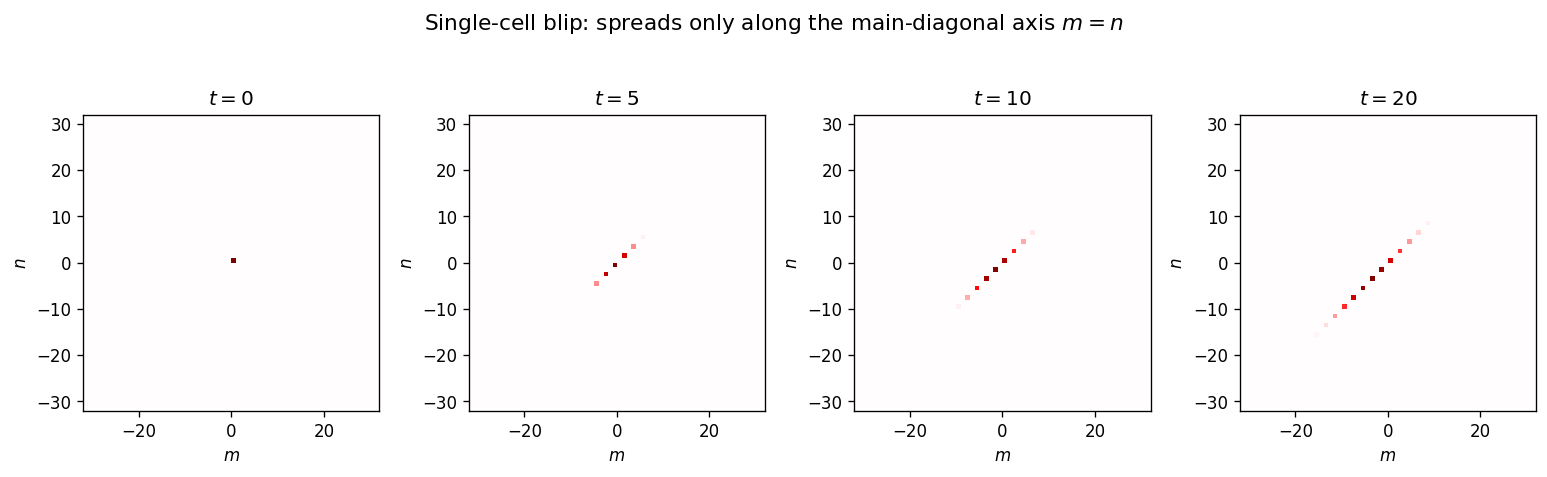

In [4]:
# Initial condition: a single active cell at the centre
u0 = np.zeros((N, N))
u0[N//2, N//2] = 1.0

frames = simulate(u0, T=20)

# Show 4 snapshots
fig, axes = plt.subplots(1, 4, figsize=(13, 4))
for ax, t in zip(axes, [0, 5, 10, 20]):
    # Normalise each frame so colours don't blow up
    clip = max(np.max(np.abs(frames[t])), 1e-12)
    ax.imshow(frames[t] / clip, cmap='seismic', vmin=-1, vmax=1,
              origin='lower', interpolation='nearest',
              extent=[-N//2, N//2, -N//2, N//2])
    ax.set_title(f'$t = {t}$', fontsize=12)
    ax.set_xlabel('$m$'); ax.set_ylabel('$n$')

fig.suptitle('Single-cell blip: spreads only along the main-diagonal axis $m = n$',
             fontsize=13)
plt.tight_layout()
plt.show()

Notice anything?

The signal spreads only along **one diagonal** — the NE/SW direction.
The other diagonal carries nothing. The rule only couples NE and SW neighbours,
so information can only travel along that axis. Nothing surprising yet.

But look at the *growth*...

---
### Experiment 2: How fast does it grow?

In [5]:
# Total activity = sum of |u[m,n]| over all cells
energies = [np.sum(np.abs(f)) for f in frames]

print(f"{'t':>4}   {'total activity':>18}   {'ratio to previous':>18}")
print('-' * 46)
for t, e in enumerate(energies):
    ratio = f'{e / energies[t-1]:.6f}' if t > 0 else '        —'
    print(f"{t:>4}   {e:>18.4f}   {ratio:>18}")

   t       total activity    ratio to previous
----------------------------------------------
   0               1.0000                    —
   1               2.0000             2.000000
   2               4.0000             2.000000
   3               8.0000             2.000000
   4              16.0000             2.000000
   5              32.0000             2.000000
   6              64.0000             2.000000
   7             128.0000             2.000000
   8             256.0000             2.000000
   9             512.0000             2.000000
  10            1024.0000             2.000000
  11            2048.0000             2.000000
  12            4096.0000             2.000000
  13            8192.0000             2.000000
  14           16384.0000             2.000000
  15           32768.0000             2.000000
  16           65536.0000             2.000000
  17          131072.0000             2.000000
  18          262144.0000             2.000000
  19         

Each step the total activity **doubles**. Always. Every single step.

Yet neither $p = 1.2$ nor $q = 0.8$ equals $2$.

Where does $2$ come from?

> **Spoiler:** $1.2 + 0.8 = 2$. But *why* is it the sum? That is a linear algebra story,
> and you will be able to prove it rigorously by week 6 of this course.
> For now, just notice it.

---
### Experiment 3: Does direction matter?

Instead of a single blip, let's seed the grid with a **wave pattern** running
along each diagonal and see what happens.

- **Anti-diagonal wave:** $u_{m,n} = \cos\!\left(\tfrac{2\pi K(m-n)}{N}\right)$ — stripes running NW→SE
- **Main-diagonal wave:** $u_{m,n} = \cos\!\left(\tfrac{2\pi K(m+n)}{N}\right)$ — stripes running NE→SW

We'll use $K = 8$ oscillations across the grid.

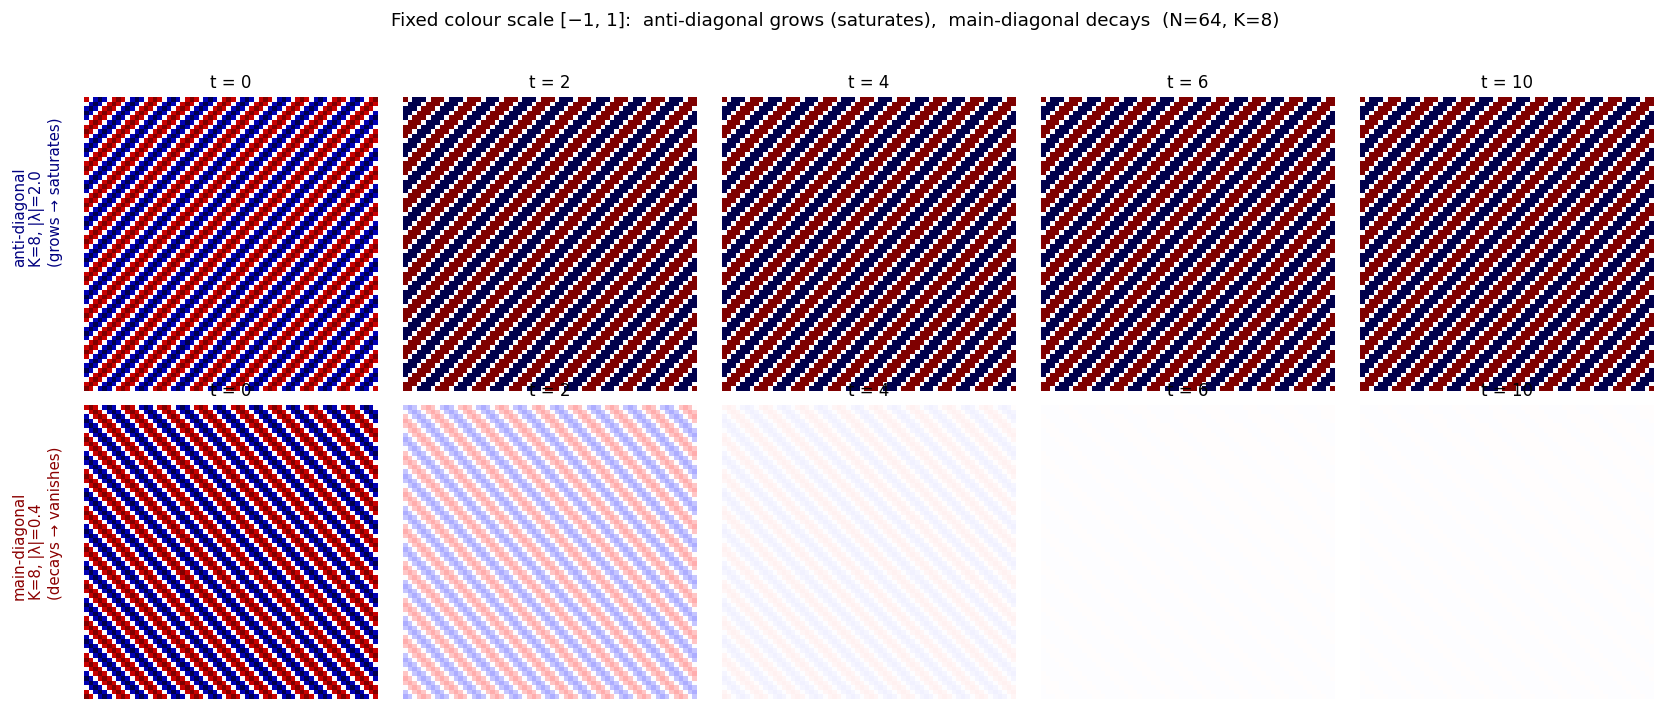

In [6]:
m_idx, n_idx = np.meshgrid(np.arange(N), np.arange(N), indexing='ij')

K = 8  # number of full oscillations across the grid

# Anti-diagonal wave: constant along m+n lines, oscillates along m-n
u_anti = np.cos(2 * np.pi * K * (m_idx - n_idx) / N)
# Main-diagonal wave: constant along m-n lines, oscillates along m+n
u_main = np.cos(2 * np.pi * K * (m_idx + n_idx) / N)

anti_frames = simulate(u_anti, T=10)
main_frames = simulate(u_main, T=10)

T_show = [0, 2, 4, 6, 10]
fig, axes = plt.subplots(2, len(T_show), figsize=(14, 6))

for j, t in enumerate(T_show):
    for row, frames, lam_label in [
        (0, anti_frames, f'|λ| = p+q = 2.0'),
        (1, main_frames, f'|λ| = |p−q| = 0.4'),
    ]:
        # Keep the original colour scale (don't normalise) so growth/decay is visible
        axes[row, j].imshow(frames[t], cmap='seismic', vmin=-1, vmax=1,
                            origin='lower', interpolation='nearest')
        axes[row, j].set_title(f't = {t}', fontsize=10)
        axes[row, j].axis('off')

# Row labels
fig.text(0.01, 0.73, f'anti-diagonal\nK={K}, |λ|=2.0\n(grows → saturates)',
         va='center', fontsize=9, rotation=90, color='navy')
fig.text(0.01, 0.27, f'main-diagonal\nK={K}, |λ|=0.4\n(decays → vanishes)',
         va='center', fontsize=9, rotation=90, color='darkred')

fig.suptitle(
    f'Fixed colour scale [−1, 1]:  anti-diagonal grows (saturates),  '
    f'main-diagonal decays  (N={N}, K={K})',
    fontsize=11)
plt.tight_layout(rect=[0.04, 0, 1, 0.95])
plt.show()

**So direction matters — a lot.**

- The **anti-diagonal wave** keeps its shape and grows: after 10 steps it is $2^{10} = 1024$ times bigger
  (so big that it clips the colour scale — that's why it goes fully red/blue).
- The **main-diagonal wave at $K=8$** shrinks: after 10 steps its amplitude is $0.4^{10} \approx 10^{-4}$
  — nearly invisible.

And here is the remarkable part: *every* anti-diagonal wave (any wavelength) grows at the same rate $p + q = 2$.
Main-diagonal waves grow or shrink depending on their wavelength.

**Why?** The answer is eigenvalues.

---
## §4 — The Full Picture

Every wave on the grid has a direction: it can run NE, or NW, or anywhere in between.
The plot below colours every possible wave direction by its growth rate under one step of the rule.

The code generates that map. You don't need to understand every line right now —
just look at the result.

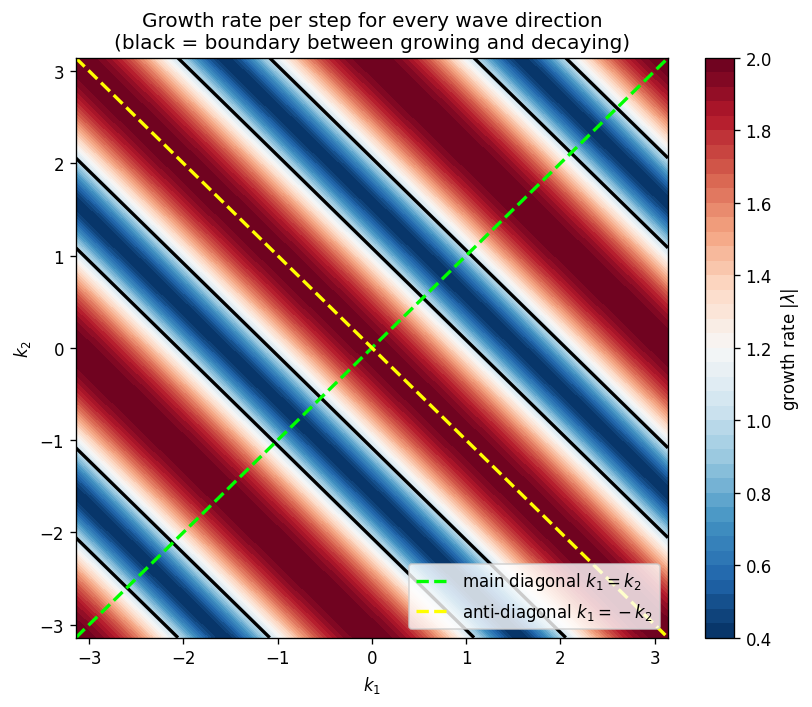

Max growth rate: 2.0000  (= p+q = 2.0)
Min growth rate: 0.4000  (= |p-q| = 0.3999999999999999)


In [7]:
# Build a grid of all wave directions (k1, k2) in [-pi, pi)
k1 = np.linspace(-np.pi, np.pi, 512)
k2 = np.linspace(-np.pi, np.pi, 512)
K1, K2 = np.meshgrid(k1, k2, indexing='ij')

# Growth rate of the wave e^{i(k1*m + k2*n)} under one step
# (derived using the eigenvalue formula — we'll prove this later)
growth_rate = np.sqrt(p**2 + q**2 + 2*p*q * np.cos(2*(K1 + K2)))

fig, ax = plt.subplots(figsize=(7, 6))
cf = ax.contourf(k1, k2, growth_rate, levels=50, cmap='RdBu_r')
plt.colorbar(cf, ax=ax, label='growth rate $|\\lambda|$')

# Black curve = stability boundary (growth rate exactly 1)
ax.contour(k1, k2, growth_rate, levels=[1.0], colors='k', linewidths=2)

# Mark the two diagonal axes
ax.axline((0,0), slope= 1, color='lime',   lw=2, ls='--', label='main diagonal $k_1=k_2$')
ax.axline((0,0), slope=-1, color='yellow', lw=2, ls='--', label='anti-diagonal $k_1=-k_2$')

ax.set(xlabel='$k_1$', ylabel='$k_2$',
       title='Growth rate per step for every wave direction\n(black = boundary between growing and decaying)')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

print(f'Max growth rate: {growth_rate.max():.4f}  (= p+q = {p+q})')
print(f'Min growth rate: {growth_rate.min():.4f}  (= |p-q| = {abs(p-q)})')

Each point in this picture is one wave direction. **Red = growing, blue = decaying.**

- The **yellow dashed line** (anti-diagonal, $k_1 = -k_2$) lies entirely in the red zone: every anti-diagonal wave grows at rate $p+q = 2$, no exceptions.
- The **green dashed line** (main diagonal, $k_1 = k_2$) runs from deep red (growth 2) to deep blue (growth 0.4), crossing the stability boundary twice.

By the end of this course you will be able to derive this picture from scratch,
starting from the definition of a matrix and eigenvalues.

---
## §5 — What This Course Will Teach You

Here is what the next few months are about, in plain terms.

1. **Vectors and linear maps.** The rule $u \mapsto Tu$ is a *linear map*.
   Linear maps are the centrepiece of the course.

2. **Eigenvalues and eigenvectors.** The waves in §3 are *eigenvectors* of $T$.
   Their growth rates are *eigenvalues*. Once you know them, you can predict everything.

3. **Change of basis.** Switching to the 'wave basis' (Fourier basis) turns $T$
   into a diagonal map — just multiply each wave by its growth rate.
   This is why the FFT algorithm is fast.

4. **Stability.** A system is stable when all eigenvalues have magnitude $\leq 1$.
   The black curve in §4 is exactly the set of unstable waves.

---

Here is the full story of the glider, in plain terms.

The glider moves **north-east** because its shape has a NE bias: each tick, the cells
at the NE edge have the right neighbour counts to be born; the cells at the SW edge do not, and die.
Our linear rule copies that bias directly — NE neighbour gets weight 1.2, SW gets 0.8.

The glider **stays coherent** as it moves because the anti-diagonal direction has a special property:
every wave pattern along it grows at the *same* rate. Patterns made of many wavelengths can travel
together without falling apart. In all other directions, different wavelengths grow at different
rates and any coherent structure disperses.

Our linear model shows exactly this. The same mechanism is at work in GoL.

**By the end of this course, you will be able to prove all of this from scratch.**